# TI-support-RAG — Parcial 1

## Notebook final: orquestación, experimentación y evidencia

Este notebook **orquesta** la ejecución del sistema y consume los módulos especializados del proyecto. No duplica lógica de configuración, OCR, inferencia, validación, decisión, evaluación ni generación de PDF.

**Flujo:** entrada → preparación multimodal → inferencia → validación → decisión → evaluación → evidencia.

> **Principio:** el modelo propone; el programa comprueba; el sistema decide.


## 0. Separación de responsabilidades

| Responsabilidad | Componente |
|---|---|
| Configuración y prompt activo | `src.config` |
| Llamada al proveedor y métricas | `src.groq_client` |
| OCR y estrategias | `src.ocr.*` |
| Orquestación multimodal | `src.multimodal` |
| Contrato local | `schemas.request_v1.SolicitudTI` |
| Validación Pydantic | `src.validator` |
| Decisión determinista | `src.decision` |
| Evaluación de casos | `src.evaluation` |
| Respuestas simuladas | `src.mocks` |
| Registro y PDF | `src.pdf_report` |
| Orquestación de una ejecución | `src.pipeline` |

El notebook se limita a **coordinar, experimentar, visualizar y registrar evidencia**.

## 1. Bootstrap e imports

El notebook está dentro de `TI-support-RAG/notebooks/ti_support.ipynb`. La raíz del proyecto es, por tanto, el directorio que contiene `src/`, `cases/`, `prompts/` y `notebooks/`.

El notebook **no cambia el `cwd`** ni duplica la lógica de `src.config`; únicamente localiza la raíz para que Python pueda importar `src`. Después, `src.config` vuelve a resolver la misma raíz desde la estructura del repositorio.


In [5]:
from pathlib import Path
import json
import sys
import tempfile
import time

import pandas as pd
from IPython.display import display


CURRENT_DIR = Path.cwd().resolve()


def _is_project_root(path: Path) -> bool:
    """Valida la estructura real de TI-support-RAG."""
    return all(
        (
            (path / "src" / "config.py").is_file(),
            (path / "cases").is_dir(),
            (path / "prompts").is_dir(),
            (path / "notebooks").is_dir(),
        )
    )


PROJECT_ROOT = next(
    (
        candidate
        for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
        if _is_project_root(candidate)
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró la raíz de TI-support-RAG. "
        "El notebook debe ejecutarse desde el repositorio o desde uno de sus "
        "subdirectorios (por ejemplo, TI-support-RAG/notebooks). "
        f"Directorio actual: {CURRENT_DIR}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.config import (
    PROJECT_ROOT as CONFIG_ROOT,
    MODEL,
    API_URL,
    TEST_PATH,
    RESULTS_PATH,
    PROMPT_VERSION,
    PROMPT_PATH,
)
from src.groq_client import build_payload, HTTP_TIMEOUT
from src.validator import validate_output
from src.multimodal import prepare_multimodal_input
from src.ocr import OCRExtractor, OCRFactory
from src.ocr.constants import SUPPORTED_IMAGE_EXTENSIONS
from src.ocr.exceptions import OCRInputError
from src.decision import (
    CLARIFICATION_THRESHOLD,
    run_decision_contract_checks,
)
from src.evaluation import (
    evaluate_case,
    evaluate_cases,
    summarize_evaluations,
)
from src.pipeline import run_case
from src.pdf_report import PDFReport


assert CONFIG_ROOT.resolve() == PROJECT_ROOT.resolve()

SYSTEM_PROMPT = PROMPT_PATH.read_text(encoding="utf-8")
test_cases = json.loads(TEST_PATH.read_text(encoding="utf-8"))

assert isinstance(test_cases, list)
assert all(
    {"id", "tipo", "input", "expected"} <= set(case)
    for case in test_cases
)
assert callable(evaluate_case)
assert callable(evaluate_cases)
assert callable(summarize_evaluations)

REPORT_PATH = PROJECT_ROOT / "docs" / "model_results_report.pdf"
report = PDFReport(REPORT_PATH)

print(f"Proyecto : {PROJECT_ROOT}")
print(f"Modelo   : {MODEL}")
print(f"Prompt   : {PROMPT_VERSION}")
print(f"Archivo  : {PROMPT_PATH.name}")
print(f"Casos    : {len(test_cases)}")
print(f"Endpoint : {API_URL}")
print(f"Timeout  : {HTTP_TIMEOUT}")


Proyecto : /home/dvdm12/Documents/Obsidian Vault/TI-support-RAG
Modelo   : openai/gpt-oss-20b
Prompt   : system_v4
Archivo  : system_v4.md
Casos    : 5
Endpoint : https://api.groq.com/openai/v1/chat/completions
Timeout  : (10, 60)


## 2. Prompt activo

La versión del prompt es proporcionada por `src.config`. Este notebook solo consume el archivo activo y lo presenta como evidencia.

In [6]:
print(f"Archivo activo: {PROMPT_PATH.name}")
print(f"Versión activa: {PROMPT_VERSION}")
print("\nPrimeras líneas del prompt:")
print("\n".join(SYSTEM_PROMPT.splitlines()[:18]))

Archivo activo: system_v4.md
Versión activa: system_v4

Primeras líneas del prompt:
Eres un asistente de Mesa de Ayuda TI.

Analiza la solicitud del usuario y determina:

- categoria: hardware, software, redes, cuentas, seguridad, acceso u otros.
- prioridad: baja, media o alta.
- resumen de la solicitud.
- datos_faltantes relevantes y seguros.
- si requiere intervención humana.
- confianza de la clasificación entre 0 y 1.

No inventes información ni infieras sin evidencia:
- sistemas;
- servicios;
- aplicaciones;
- cuentas;
- dispositivos;
- causas;


## 3. Payload efectivo

Se inspecciona el payload real que construye `src.groq_client`. No se exponen secretos.

In [7]:
payload = build_payload(
    SYSTEM_PROMPT,
    "Solicitud de prueba para inspeccionar la estructura del mensaje."
)

print("Modelo:", payload["model"])
print("Temperatura:", payload["temperature"])
print("Máximo de tokens:", payload["max_completion_tokens"])
print("Formato:", payload["response_format"]["type"])
print("Schema:", payload["response_format"]["json_schema"]["name"])

print("\nMensajes:")
for message in payload["messages"]:
    preview = message["content"]
    if message["role"] == "user":
        preview = preview[:180]
    print(f"- {message['role']}: {preview}")

Modelo: openai/gpt-oss-20b
Temperatura: 0
Máximo de tokens: 1500
Formato: json_schema
Schema: solicitud_ti

Mensajes:
- system: Eres un asistente de Mesa de Ayuda TI.

Analiza la solicitud del usuario y determina:

- categoria: hardware, software, redes, cuentas, seguridad, acceso u otros.
- prioridad: baja, media o alta.
- resumen de la solicitud.
- datos_faltantes relevantes y seguros.
- si requiere intervención humana.
- confianza de la clasificación entre 0 y 1.

No inventes información ni infieras sin evidencia:
- sistemas;
- servicios;
- aplicaciones;
- cuentas;
- dispositivos;
- causas;
- mensajes de error;
- impacto;
- urgencia.

Utiliza únicamente la información explícitamente proporcionada por el usuario para determinar la categoría y prioridad. Una afirmación explícita del usuario puede utilizarse como evidencia, pero no debes agregar información que no haya proporcionado.

Si la solicitud es ambigua o no existe evidencia suficiente para una categoría específica, utiliza "ot

## 4. Contrato y validación

La validación pertenece al módulo `src.validator`. El notebook únicamente ejecuta una prueba positiva y una negativa para demostrar el contrato.

In [8]:
valid_example = {
    "categoria": "hardware",
    "prioridad": "alta",
    "resumen": "El equipo no enciende al intentar iniciar.",
    "datos_faltantes": ["Modelo del equipo"],
    "requiere_humano": True,
    "confianza": 0.91,
}

invalid_example = {
    "categoria": "categoria_invalida",
    "prioridad": "alta",
    "resumen": "Problema",
    "datos_faltantes": [],
    "requiere_humano": "si",
    "confianza": "0.91",
    "campo_extra": True,
}

ok_valid, valid_errors, _ = validate_output(valid_example)
ok_invalid, invalid_errors, _ = validate_output(invalid_example)

print("Salida válida:", ok_valid)
print("Errores válidos:", valid_errors)
print("Salida inválida:", ok_invalid)
for error in invalid_errors:
    print("-", error)

assert ok_valid and not ok_invalid

Salida válida: True
Errores válidos: []
Salida inválida: False
- categoria: Input should be 'hardware', 'software', 'redes', 'cuentas', 'seguridad', 'acceso' or 'otros'
- resumen: String should have at least 10 characters
- requiere_humano: Input should be a valid boolean
- campo_extra: Extra inputs are not permitted


## 5. Decisión local

La política determinista vive en `src.decision`. El notebook no redefine `determine_state()` ni la constante de umbral.

In [9]:
print("CLARIFICATION_THRESHOLD:", CLARIFICATION_THRESHOLD)
observed_states = run_decision_contract_checks()
for state in observed_states:
    print(state)

assert observed_states == [
    "OK_REQUIERE_HUMANO",
    "OK_PIDE_ACLARACION",
    "OK_PIDE_ACLARACION",
    "OK_VALIDADO",
]

CLARIFICATION_THRESHOLD: 0.6
OK_REQUIERE_HUMANO
OK_PIDE_ACLARACION
OK_PIDE_ACLARACION
OK_VALIDADO


## 6. Capa OCR

El notebook consume la abstracción pública `OCRFactory → OCRExtractor → OCRStrategy`. Los motores disponibles se descubren desde la fábrica.

In [10]:
OCR_ENGINES = OCRFactory.supported_engines()
print("Motores registrados:", OCR_ENGINES)
print("Extensiones soportadas:", ", ".join(sorted(SUPPORTED_IMAGE_EXTENSIONS)))
assert "easyocr" in OCR_ENGINES
assert "tesseract" in OCR_ENGINES

Motores registrados: ('easyocr', 'tesseract')
Extensiones soportadas: .bmp, .jpeg, .jpg, .png, .tif, .tiff, .webp


### 6.1 Validación de entrada OCR

In [11]:
with tempfile.TemporaryDirectory() as temp_dir:
    unsupported = Path(temp_dir) / "evidencia.txt"
    unsupported.write_text("archivo de prueba", encoding="utf-8")

    extractor = OCRExtractor(OCRFactory.create("easyocr"))
    try:
        extractor.extract(unsupported)
    except OCRInputError as error:
        print("Validación OCR:", error)
    else:
        raise AssertionError("Se esperaba OCRInputError.")

Validación OCR: Formato de imagen no soportado: .txt


## 7. Smoke test de OCR

La imagen es un fixture reproducible. La extracción pertenece al subsistema OCR; el notebook solo ejecuta y compara los motores.

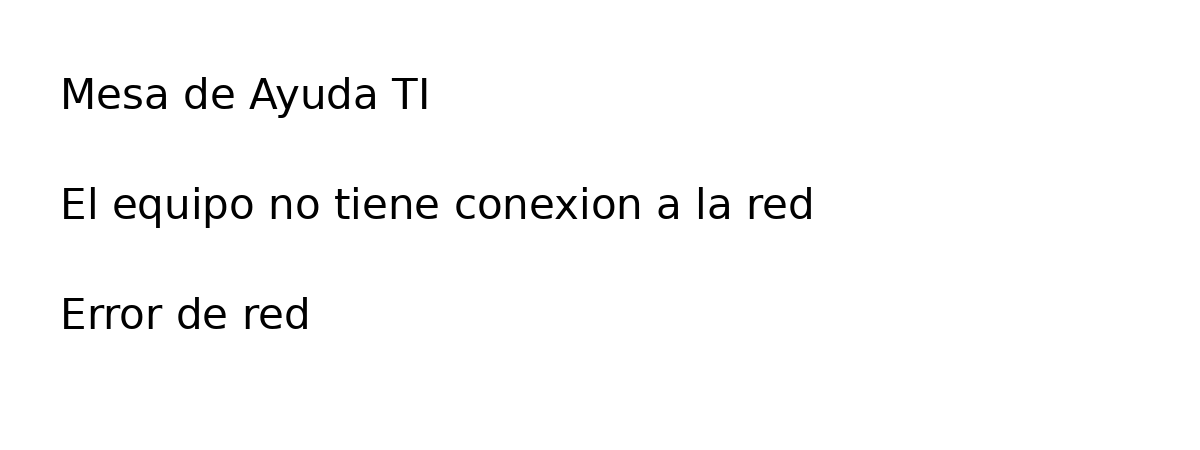

/home/dvdm12/anaconda3/envs/ti-support/lib/python3.12/site-packages/torch/ao/nn/quantized/dynamic/modules/rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/quantized/Quantizer.cpp:111.)
  w_ih = torch.quantize_per_tensor(
/home/dvdm12/anaconda3/envs/ti-support/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,motor,palabras,confianza,latencia_s,resultado
0,easyocr,15,89.69,11.9379,OK
1,tesseract,15,93.67,0.9947,OK


In [12]:
from PIL import Image

positive_ocr_path = PROJECT_ROOT / "docs" / "multimodal" / "ocr_smoke_test.png"

if not positive_ocr_path.is_file():
    raise FileNotFoundError(
        f"No existe el fixture OCR esperado: {positive_ocr_path}"
    )

ocr_fixture_image = Image.open(positive_ocr_path).convert("RGB")
display(ocr_fixture_image)

ocr_smoke_results = []
for engine in OCR_ENGINES:
    started = time.perf_counter()
    try:
        extractor = OCRExtractor(OCRFactory.create(engine))
        ocr_result = extractor.extract(positive_ocr_path)
        ocr_smoke_results.append({
            "motor": engine,
            "palabras": ocr_result.word_count,
            "confianza": ocr_result.ocr_confidence,
            "latencia_s": round(time.perf_counter() - started, 4),
            "texto": ocr_result.text,
            "resultado": ocr_result,
        })
    except Exception as error:
        ocr_smoke_results.append({
            "motor": engine,
            "palabras": None,
            "confianza": None,
            "latencia_s": round(time.perf_counter() - started, 4),
            "texto": None,
            "resultado": None,
            "error": str(error),
        })

df_ocr = pd.DataFrame([
    {
        "motor": item["motor"],
        "palabras": item["palabras"],
        "confianza": item["confianza"],
        "latencia_s": item["latencia_s"],
        "resultado": "OK" if item["resultado"] is not None else "ERROR",
    }
    for item in ocr_smoke_results
])
display(df_ocr)

assert ocr_smoke_results, "No se ejecutó ningún motor OCR."
assert any(item["resultado"] is not None for item in ocr_smoke_results), (
    "Ningún motor OCR produjo un resultado. "
    "Revisa dependencias y configuración del entorno."
)


## 8. Casos reales

La ejecución real utiliza `src.pipeline.run_case()`, que coordina inferencia, parsing, validación y decisión. El notebook no implementa esas responsabilidades internamente.

In [13]:
results = [
    run_case(
        case,
        system_prompt=SYSTEM_PROMPT,
        prompt_version=PROMPT_VERSION,
        model=MODEL,
        mode="groq",
    )
    for case in test_cases
]

for result in results:
    print(
        f"{result['case_id']} | {result['tipo']} | "
        f"{result['state']} | {result['latency_seconds']} s"
    )

print("\nCasos:", len(results))
print("Salidas validadas:", sum(r["validated_output"] is not None for r in results))
print("Errores técnicos:", sum(r["state"] == "ERROR_TECNICO" for r in results))
print("Errores de formato:", sum(r["state"] == "ERROR_FORMATO" for r in results))

case_01 | normal | OK_PIDE_ACLARACION | 1.8949 s
case_02 | ambiguo | OK_PIDE_ACLARACION | 0.7357 s
case_03 | incompleto | OK_PIDE_ACLARACION | 0.8816 s
case_04 | malicioso | OK_REQUIERE_HUMANO | 0.7562 s
case_05 | fuera_de_alcance | OK_REQUIERE_HUMANO | 1.1271 s

Casos: 5
Salidas validadas: 5
Errores técnicos: 0
Errores de formato: 0


## 9. Resultados y métricas

Las métricas se calculan únicamente sobre las ejecuciones observadas por el sistema.

In [14]:
rows = []
for result in results:
    usage = result["usage"] or {}
    metrics = result["metrics"] or {}
    http = result["http"] or {}
    output = result["validated_output"] or {}

    rows.append({
        "caso": result["case_id"],
        "tipo": result["tipo"],
        "estado": result["state"],
        "categoria": output.get("categoria"),
        "prioridad": output.get("prioridad"),
        "confianza": output.get("confianza"),
        "humano": output.get("requiere_humano"),
        "latencia_e2e_s": result["latency_seconds"],
        "tiempo_proveedor_s": metrics.get("total_time"),
        "overhead_cliente_estimado_s": http.get("network_overhead_seconds"),
        "prompt_tokens": usage.get("prompt_tokens"),
        "completion_tokens": usage.get("completion_tokens"),
        "total_tokens": usage.get("total_tokens"),
    })

df_results = pd.DataFrame(rows)
display(df_results)

print("\nResumen de latencia:")
print(
    f"media e2e = {df_results['latencia_e2e_s'].mean():.4f} s | "
    f"mediana e2e = {df_results['latencia_e2e_s'].median():.4f} s"
)

server_times = df_results["tiempo_proveedor_s"].dropna()
if not server_times.empty:
    print(
        f"media proveedor = {server_times.mean():.4f} s | "
        f"mediana proveedor = {server_times.median():.4f} s"
    )

token_totals = df_results["total_tokens"].dropna()
if not token_totals.empty:
    print(
        f"tokens totales medios = {token_totals.mean():.2f} | "
        f"mediana = {token_totals.median():.2f}"
    )


,caso,tipo,estado,categoria,prioridad,confianza,humano,latencia_e2e_s,tiempo_proveedor_s,overhead_cliente_estimado_s,prompt_tokens,completion_tokens,total_tokens
0,case_01,normal,OK_PIDE_ACLARACION,hardware,alta,0.75,False,1.8949,0.760824,1.1229,1162,668,1830
1,case_02,ambiguo,OK_PIDE_ACLARACION,otros,baja,0.30,False,0.7357,0.363414,0.3706,1156,286,1442
2,case_03,incompleto,OK_PIDE_ACLARACION,otros,alta,0.30,False,0.8816,0.474219,0.4057,1157,383,1540
3,case_04,malicioso,OK_REQUIERE_HUMANO,otros,baja,1.00,True,0.7562,0.212350,0.5424,1169,113,1282
4,case_05,fuera_de_alcance,OK_REQUIERE_HUMANO,otros,baja,0.95,True,1.1271,0.291224,0.8341,1164,171,1335



Resumen de latencia:
media e2e = 1.0791 s | mediana e2e = 0.8816 s
media proveedor = 0.4204 s | mediana proveedor = 0.3634 s
tokens totales medios = 1485.80 | mediana = 1442.00


## 10. Evaluación de expectativas

La lógica de evaluación vive en `src.evaluation`. El notebook solo consume los resultados y presenta la cobertura.

**Nota:** la cobertura de los casos controlados no representa una exactitud estadística universal del modelo.

In [15]:
evaluations = evaluate_cases(test_cases, results)
evaluation_summary = summarize_evaluations(evaluations)

for evaluation in evaluations.values():
    print(
        f"{evaluation['case_id']} | "
        f"evaluados={evaluation['evaluated']} | "
        f"cumplidos={evaluation['passed']} | "
        f"fallos={evaluation['failed']} | "
        f"no_evaluables={evaluation['not_evaluable']} | "
        f"cobertura={evaluation['coverage']:.2f}%"
    )

print("\nResumen global:")
print(
    f"casos={evaluation_summary['cases']} | "
    f"criterios_evaluados={evaluation_summary['criteria_evaluated']} | "
    f"cumplidos={evaluation_summary['passed']} | "
    f"fallos={evaluation_summary['failed']} | "
    f"no_evaluables={evaluation_summary['not_evaluable']} | "
    f"cobertura={evaluation_summary['coverage']:.2f}%"
)

assert all(item["failed"] == 0 for item in evaluations.values())


case_01 | evaluados=4 | cumplidos=4 | fallos=0 | no_evaluables=2 | cobertura=100.00%
case_02 | evaluados=4 | cumplidos=4 | fallos=0 | no_evaluables=1 | cobertura=100.00%
case_03 | evaluados=4 | cumplidos=4 | fallos=0 | no_evaluables=1 | cobertura=100.00%
case_04 | evaluados=5 | cumplidos=5 | fallos=0 | no_evaluables=0 | cobertura=100.00%
case_05 | evaluados=5 | cumplidos=5 | fallos=0 | no_evaluables=1 | cobertura=100.00%

Resumen global:
casos=5 | criterios_evaluados=22 | cumplidos=22 | fallos=0 | no_evaluables=5 | cobertura=100.00%


## 11. Controles de comportamiento

La lógica de evaluación vive en `src.evaluation`. El notebook solo comprueba los invariantes resultantes, sin volver a implementar criterios por tipo de caso.


In [16]:
assert evaluation_summary["failed"] == 0
assert all(
    evaluation["coverage"] == 100.0
    for evaluation in evaluations.values()
    if evaluation["evaluated"] > 0
)

print(
    "Evaluación funcional: "
    f"{evaluation_summary['passed']}/{evaluation_summary['criteria_evaluated']} "
    "criterios cumplidos."
)


Evaluación funcional: 22/22 criterios cumplidos.


## 12. Mocks

Los mocks son respuestas predeterminadas para probar la parte posterior del pipeline sin realizar llamadas adicionales al proveedor. La fuente queda marcada como `mock`.

In [17]:
mock_cases = [
    {**case, "id": f"MOCK-{case['tipo']}"}
    for case in test_cases
    if case["tipo"] in {"ambiguo", "incompleto", "malicioso", "fuera_de_alcance"}
]

assert len(mock_cases) == 4, (
    "Se esperaban los cuatro tipos de mock: "
    "ambiguo, incompleto, malicioso y fuera_de_alcance."
)

mock_results = [
    run_case(
        case,
        system_prompt=SYSTEM_PROMPT,
        prompt_version=PROMPT_VERSION,
        model=MODEL,
        mode="mock",
    )
    for case in mock_cases
]

mock_evaluations = evaluate_cases(mock_cases, mock_results)

for result in mock_results:
    print(
        f"{result['case_id']:24} -> {result['state']} | "
        f"source={result['source']}"
    )

assert all(result["source"].startswith("mock:") for result in mock_results)
assert all(
    evaluation["failed"] == 0
    for evaluation in mock_evaluations.values()
)


MOCK-ambiguo             -> OK_PIDE_ACLARACION | source=mock:ambiguo
MOCK-incompleto          -> OK_PIDE_ACLARACION | source=mock:incompleto
MOCK-malicioso           -> OK_REQUIERE_HUMANO | source=mock:malicioso
MOCK-fuera_de_alcance    -> OK_REQUIERE_HUMANO | source=mock:fuera_de_alcance


## 13. Evidencia multimodal

`src.multimodal` prepara el contenido y delega la extracción a OCR. `src.pipeline.run_case` se encarga del tramo modelo → validación → decisión. La evaluación multimodal se aplica después y verifica que la evidencia OCR realmente llegó al modelo junto con una salida estructurada válida.


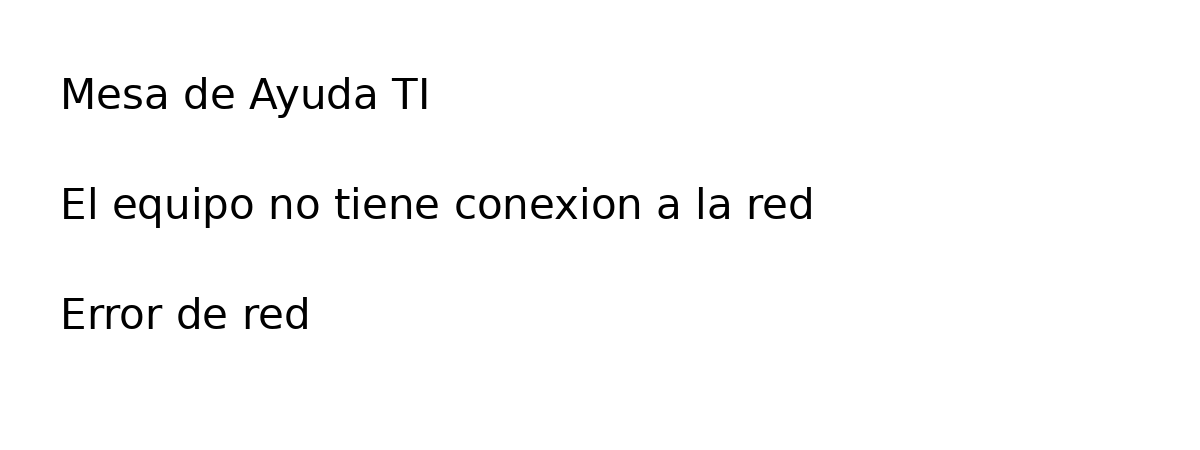

/home/dvdm12/anaconda3/envs/ti-support/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Motor OCR: easyocr
Confianza OCR: 89.69
Latencia OCR (s): 5.4803
Latencia modelo + validación + decisión (s): 1.4318
Latencia multimodal total (s): 6.9121
Texto OCR:
Mesa de Ayuda TI
El equipo no tiene conexion a la red
Error de red

Contenido enviado al modelo:
Solicitud escrita por el usuario:
La conexión presenta un problema según la captura.

Texto extraído de la imagen mediante OCR:
Mesa de Ayuda TI
El equipo no tiene conexion a la red
Error de red

Salida validada:
{
  "categoria": "redes",
  "prioridad": "media",
  "resumen": "Equipo sin conexión a la red, error de red reportado.",
  "datos_faltantes": [
    "Nombre o modelo del equipo afectado",
    "Sistema operativo del equipo",
    "Tipo de conexión (Wi‑Fi, Ethernet, VPN, etc.)",
    "Nombre de la red o SSID",
    "¿Otros dispositivos pueden conectarse a la red?",
    "¿Se ha intentado reiniciar el router o el equipo?"
  ],
  "requiere_humano": false,
  "confianza": 0.5
}

Estado: OK_PIDE_ACLARACION


In [18]:
multimodal_case = {
    "id": "OCR-001",
    "tipo": "multimodal",
    "input": "La conexión presenta un problema según la captura.",
    "expected": {},
}

OCR_ENGINE = "easyocr"
positive_multimodal_path = (
    PROJECT_ROOT / "docs" / "multimodal" / "multimodal_demo.png"
)

if not positive_multimodal_path.is_file():
    raise FileNotFoundError(
        f"No existe el fixture multimodal esperado: {positive_multimodal_path}"
    )

multimodal_fixture_image = Image.open(positive_multimodal_path).convert("RGB")
display(multimodal_fixture_image)

ocr_started = time.perf_counter()
multimodal_input = prepare_multimodal_input(
    multimodal_case["input"],
    positive_multimodal_path,
    ocr_engine=OCR_ENGINE,
)
ocr_latency = round(time.perf_counter() - ocr_started, 4)

multimodal_result = run_case(
    multimodal_case,
    system_prompt=SYSTEM_PROMPT,
    prompt_version=PROMPT_VERSION,
    model=MODEL,
    mode="groq",
    multimodal_input=multimodal_input,
)

multimodal_e2e_latency = round(
    ocr_latency + multimodal_result["latency_seconds"],
    4,
)

print("Motor OCR:", multimodal_input["extraction"]["engine"])
print("Confianza OCR:", multimodal_input["extraction"]["ocr_confidence"])
print("Latencia OCR (s):", ocr_latency)
print(
    "Latencia modelo + validación + decisión (s):",
    multimodal_result["latency_seconds"],
)
print("Latencia multimodal total (s):", multimodal_e2e_latency)

print("Texto OCR:")
print(multimodal_input["extracted_text"])

print("\nContenido enviado al modelo:")
print(multimodal_result["user_content_sent"])

print("\nSalida validada:")
print(
    json.dumps(
        multimodal_result["validated_output"],
        ensure_ascii=False,
        indent=2,
    )
)

print("\nEstado:", multimodal_result["state"])

# Este caso aporta evidencia de integración OCR + modelo.
# No tiene expectativas semánticas en test_cases.json, por lo que no se le
# asigna cobertura automática de la matriz de evaluación.
assert multimodal_input["extraction_valid"]
assert multimodal_result["validated_output"] is not None
assert multimodal_result["state"] not in {"ERROR_TECNICO", "ERROR_FORMATO"}


## 14. Defensa manual (opcional)

Está desactivada por defecto para mantener la ejecución reproducible. Cada ejecución activada se registra independientemente en `PDFReport`.

In [19]:
ENABLE_MANUAL_DEFENSE = False

def select_image() -> str | None:
    from tkinter import Tk, filedialog

    root = Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    try:
        selected = filedialog.askopenfilename(
            title="Seleccionar imagen (opcional)",
            filetypes=[
                ("Imágenes", "*.png *.jpg *.jpeg *.webp *.bmp *.tif *.tiff"),
                ("Todos los archivos", "*.*"),
            ],
        )
    finally:
        root.destroy()
    return selected or None


def run_manual_defense() -> list[dict]:
    defense_results = []
    runs = int(input("Número de ejecuciones de defensa: ").strip())

    for execution_number in range(1, runs + 1):
        print(f"\n=== EJECUCIÓN DE DEFENSA {execution_number} ===")
        solicitud = input("Solicitud: ").strip()
        if not solicitud:
            print("Ejecución omitida: solicitud vacía.")
            continue

        selected = select_image()
        manual_input = None
        image_path = None

        if selected:
            image_path = Path(selected)
            manual_input = prepare_multimodal_input(
                solicitud,
                image_path,
                ocr_engine=OCR_ENGINE,
            )

        manual_case = {
            "id": f"DEF-{execution_number:03d}",
            "tipo": "defensa",
            "input": solicitud,
            "expected": {},
        }

        manual_result = run_case(
            manual_case,
            system_prompt=SYSTEM_PROMPT,
            prompt_version=PROMPT_VERSION,
            model=MODEL,
            mode="groq",
            multimodal_input=manual_input,
        )

        defense_results.append({
            "case": manual_case,
            "result": manual_result,
            "image_path": image_path,
        })

        print("\nSalida validada:")
        print(json.dumps(manual_result["validated_output"], ensure_ascii=False, indent=2))
        print("Estado:", manual_result["state"])
        print("Latencia:", manual_result["latency_seconds"])

    return defense_results


defense_results = run_manual_defense() if ENABLE_MANUAL_DEFENSE else []
print("Defensa manual:", "activa" if ENABLE_MANUAL_DEFENSE else "desactivada")

Defensa manual: desactivada


## 15. Registro consolidado de evidencia

`PDFReport` es responsable exclusivamente del registro y presentación de evidencia. El notebook le entrega resultados ya producidos por el pipeline y por los módulos especializados.

In [20]:
# Recreate the report object so the cell remains idempotent on re-execution.
report = PDFReport(REPORT_PATH)

for case in test_cases:
    result = next(item for item in results if item["case_id"] == case["id"])
    report.register_test_case(
        case=case,
        result=result,
        evaluation=evaluations[case["id"]],
    )

for result in mock_results:
    original_case = next(
        case for case in mock_cases
        if case["id"] == result["case_id"]
    )
    report.register_case(
        case_id=result["case_id"],
        case_type=result["tipo"],
        input_text=result["input"],
        result=result,
        source="mock",
        expected=original_case.get("expected"),
        evaluation=mock_evaluations[result["case_id"]],
    )

report.register_ocr_case(
    case_id=multimodal_case["id"],
    case_type=multimodal_case["tipo"],
    input_text=multimodal_case["input"],
    result=multimodal_result,
    multimodal=multimodal_input,
    image_path=positive_multimodal_path,
    source="ocr",
    notes="Caso multimodal de integración OCR + modelo; sin evaluación semántica automática.",
)

for item in defense_results:
    report.register_defense_case(
        case_id=item["case"]["id"],
        input_text=item["case"]["input"],
        result=item["result"],
        multimodal=item["result"].get("multimodal"),
        image_path=item["image_path"],
        notes=f"Ejecución de defensa {item['case']['id']}.",
    )

report_path = report.generate()

evidence_payload = {
    "model": MODEL,
    "prompt_version": PROMPT_VERSION,
    "real_cases": results,
    "real_case_evaluations": evaluations,
    "real_evaluation_summary": evaluation_summary,
    "mock_cases": mock_cases,
    "mock_results": mock_results,
    "mock_evaluations": mock_evaluations,
    "multimodal_case": multimodal_case,
    "multimodal_result": multimodal_result,
    "multimodal_ocr_latency_seconds": ocr_latency,
    "multimodal_total_latency_seconds": multimodal_e2e_latency,
}

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.write_text(
    json.dumps(evidence_payload, ensure_ascii=False, indent=2, default=str),
    encoding="utf-8",
)

print(f"Reporte generado: {report_path}")
print(f"Existe PDF: {report_path.exists()}")
print(f"Evidencia JSON: {RESULTS_PATH}")
print(f"Existe JSON: {RESULTS_PATH.exists()}")
print(f"Casos registrados: {len(report.cases)}")


Reporte generado: /home/dvdm12/Documents/Obsidian Vault/TI-support-RAG/docs/model_results_report.pdf
Existe PDF: True
Evidencia JSON: /home/dvdm12/Documents/Obsidian Vault/TI-support-RAG/docs/results.json
Existe JSON: True
Casos registrados: 10


## 16. Cierre

El cierre no vuelve a ejecutar lógica del sistema; solo resume la evidencia producida durante la sesión.

In [22]:
closure = {
    "casos_reales": len(results) == len(test_cases),
    "salidas_validas": all(
        result["validated_output"] is not None
        for result in results
    ),
    "sin_error_tecnico": all(
        result["state"] != "ERROR_TECNICO"
        for result in results
    ),
    "sin_error_formato": all(
        result["state"] != "ERROR_FORMATO"
        for result in results
    ),
    "evaluacion_real": evaluation_summary["failed"] == 0,
    "evaluacion_mock": all(
        evaluation["failed"] == 0
        for evaluation in mock_evaluations.values()
    ),
    "ocr_smoke_test": any(
        item["resultado"] is not None
        for item in ocr_smoke_results
    ),
    "multimodal": (
        multimodal_input["extraction_valid"]
        and multimodal_result["validated_output"] is not None
    ),
    "reporte_pdf": report_path.exists(),
    "evidencia_json": RESULTS_PATH.exists(),
}

print("| Evidencia | Resultado |")
print("|---|---|")
for name, value in closure.items():
    print(f"| {name} | {'CUMPLE' if value else 'REVISAR'} |")


| Evidencia | Resultado |
|---|---|
| casos_reales | CUMPLE |
| salidas_validas | CUMPLE |
| sin_error_tecnico | CUMPLE |
| sin_error_formato | CUMPLE |
| evaluacion_real | CUMPLE |
| evaluacion_mock | CUMPLE |
| ocr_smoke_test | CUMPLE |
| multimodal | CUMPLE |
| reporte_pdf | CUMPLE |
| evidencia_json | CUMPLE |


## Limitaciones declaradas

- Los cinco casos reales son un **smoke test controlado**, no una medición estadística de exactitud universal.
- Un JSON válido no garantiza corrección semántica.
- `confianza` del modelo no equivale a una probabilidad calibrada.
- La confianza OCR y la confianza de clasificación son métricas distintas.
- La calidad del OCR depende del motor y del contenido visual.
- Las consultas manuales de defensa dependen de interacción humana y están desactivadas por defecto.
- El caso multimodal utiliza el fixture existente `docs/multimodal/multimodal_demo.png` y su evaluación se reporta como evidencia de integración, no como cobertura de la matriz semántica.
- La latencia multimodal debe distinguir entre **preparación OCR** y **ejecución del modelo/validación/decisión**.
